# Joint Intent Classification & Slot Filling — Model Comparison Report

This report provides a comprehensive comparison of three neural network architectures trained for **joint intent classification and slot filling** on the SNIPS NLU dataset.

| # | Model | Architecture |
|---|-------|-------------|
| 1 | **Encoder-Decoder** | Learned Embeddings → BiGRU Encoder → GRU Decoder |
| 2 | **Transformer** | Learned Embeddings + Positional Encoding → Transformer Encoder |
| 3 | **BERT + Encoder-Decoder** | Frozen BERT → BiGRU Encoder → GRU Decoder |

All models were trained with **identical hyperparameters** (where applicable) and **early stopping** (patience = 5 epochs) to ensure a fair comparison.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style='whitegrid', palette='colorblind', font_scale=1.15)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 150

# Load training data saved by the training notebook
with open('report_data.json', 'r') as f:
    data = json.load(f)

h1 = data['history1']
h2 = data['history2']
h3 = data['history3']
tm1 = data['test_metrics1']
tm2 = data['test_metrics2']
tm3 = data['test_metrics3']
cfg = data['config']
mp  = data['model_params']

MODEL_NAMES = ['Encoder-Decoder', 'Transformer', 'BERT + Enc-Dec']
COLORS = sns.color_palette('colorblind', 3)

print('Report data loaded successfully.')

Report data loaded successfully.


---
## 1. Training Configuration

All models shared the following hyperparameters to ensure a fair comparison.

In [2]:
config_df = pd.DataFrame([
    ('Max Sequence Length', cfg['MAX_LEN']),
    ('Batch Size', cfg['BATCH_SIZE']),
    ('Max Epochs', cfg['MAX_EPOCHS']),
    ('Early Stopping Patience', cfg['PATIENCE']),
    ('Min Delta', cfg['MIN_DELTA']),
    ('Gradient Clipping', cfg['CLIP_GRAD']),
    ('Intent Loss Weight (α)', cfg['ALPHA']),
    ('Slot Loss Weight (β)', cfg['BETA']),
    ('Dropout', cfg['DROPOUT']),
    ('LR — Encoder-Decoder', cfg['LR_ENCODER_DECODER']),
    ('LR — Transformer', cfg['LR_TRANSFORMER']),
    ('LR — BERT Model', cfg['LR_BERT']),
], columns=['Parameter', 'Value'])

print(config_df.to_string(index=False))

              Parameter   Value
    Max Sequence Length 50.0000
             Batch Size 32.0000
             Max Epochs 20.0000
Early Stopping Patience  5.0000
              Min Delta  0.0001
      Gradient Clipping  5.0000
 Intent Loss Weight (α)  1.0000
   Slot Loss Weight (β)  1.0000
                Dropout  0.3000
   LR — Encoder-Decoder  0.0010
       LR — Transformer  0.0005
        LR — BERT Model  0.0010


---
## 2. Model Architecture Summary

          Model Total Parameters Trainable Parameters Frozen Parameters  Epochs Trained  Early Stopped
Encoder-Decoder        4,608,272            4,608,272                 0              13           True
    Transformer        6,656,336            6,656,336                 0              12           True
 BERT + Enc-Dec      109,420,880            1,110,608       108,310,272              12           True


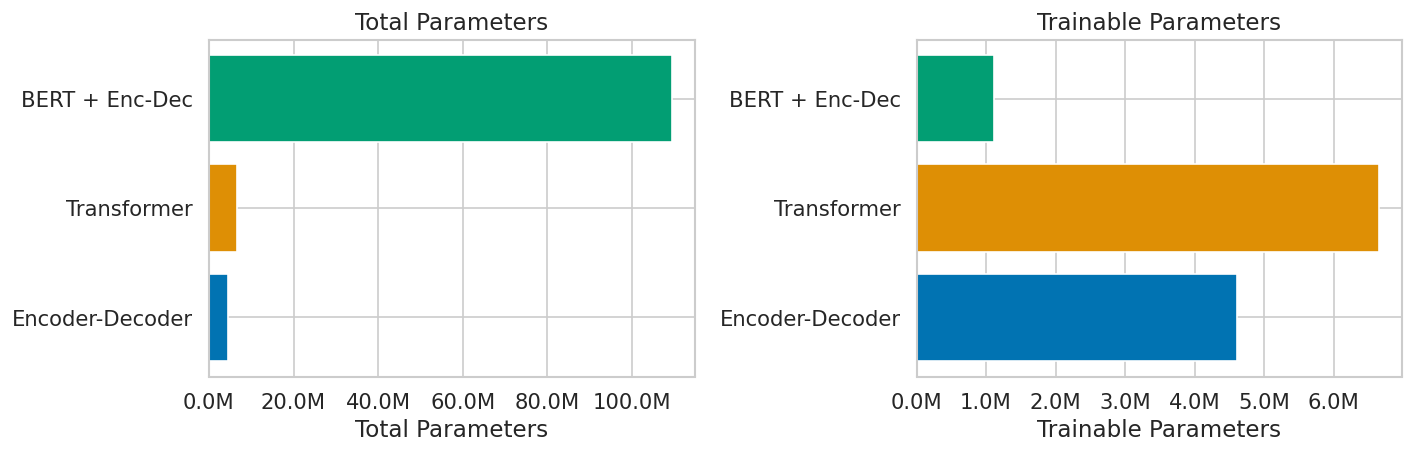

In [3]:
arch_df = pd.DataFrame({
    'Model': MODEL_NAMES,
    'Total Parameters': [f"{mp['model1_total']:,}", f"{mp['model2_total']:,}", f"{mp['model3_total']:,}"],
    'Trainable Parameters': [f"{mp['model1_trainable']:,}", f"{mp['model2_trainable']:,}", f"{mp['model3_trainable']:,}"],
    'Frozen Parameters': [
        f"{mp['model1_total'] - mp['model1_trainable']:,}",
        f"{mp['model2_total'] - mp['model2_trainable']:,}",
        f"{mp['model3_total'] - mp['model3_trainable']:,}"
    ],
    'Epochs Trained': [len(h1['train_loss']), len(h2['train_loss']), len(h3['train_loss'])],
    'Early Stopped': [
        len(h1['train_loss']) < cfg['MAX_EPOCHS'],
        len(h2['train_loss']) < cfg['MAX_EPOCHS'],
        len(h3['train_loss']) < cfg['MAX_EPOCHS'],
    ]
})

print(arch_df.to_string(index=False))

# Bar chart of parameter counts
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

trainable = [mp['model1_trainable'], mp['model2_trainable'], mp['model3_trainable']]
total     = [mp['model1_total'], mp['model2_total'], mp['model3_total']]

axes[0].barh(MODEL_NAMES, total, color=COLORS)
axes[0].set_xlabel('Total Parameters')
axes[0].set_title('Total Parameters')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

axes[1].barh(MODEL_NAMES, trainable, color=COLORS)
axes[1].set_xlabel('Trainable Parameters')
axes[1].set_title('Trainable Parameters')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

plt.tight_layout()
plt.savefig('report_params.png', bbox_inches='tight')
plt.show()

---
## 3. Training Dynamics — Loss Curves

The plots below show training and validation loss per epoch for all three models. The vertical dashed line indicates where early stopping was triggered.

/tmp/ipykernel_929801/2454977481.py:9: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-s" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(epochs, h['val_loss'], '-s', color=color, alpha=0.6, label='Val Loss', markersize=4, linestyle='--')


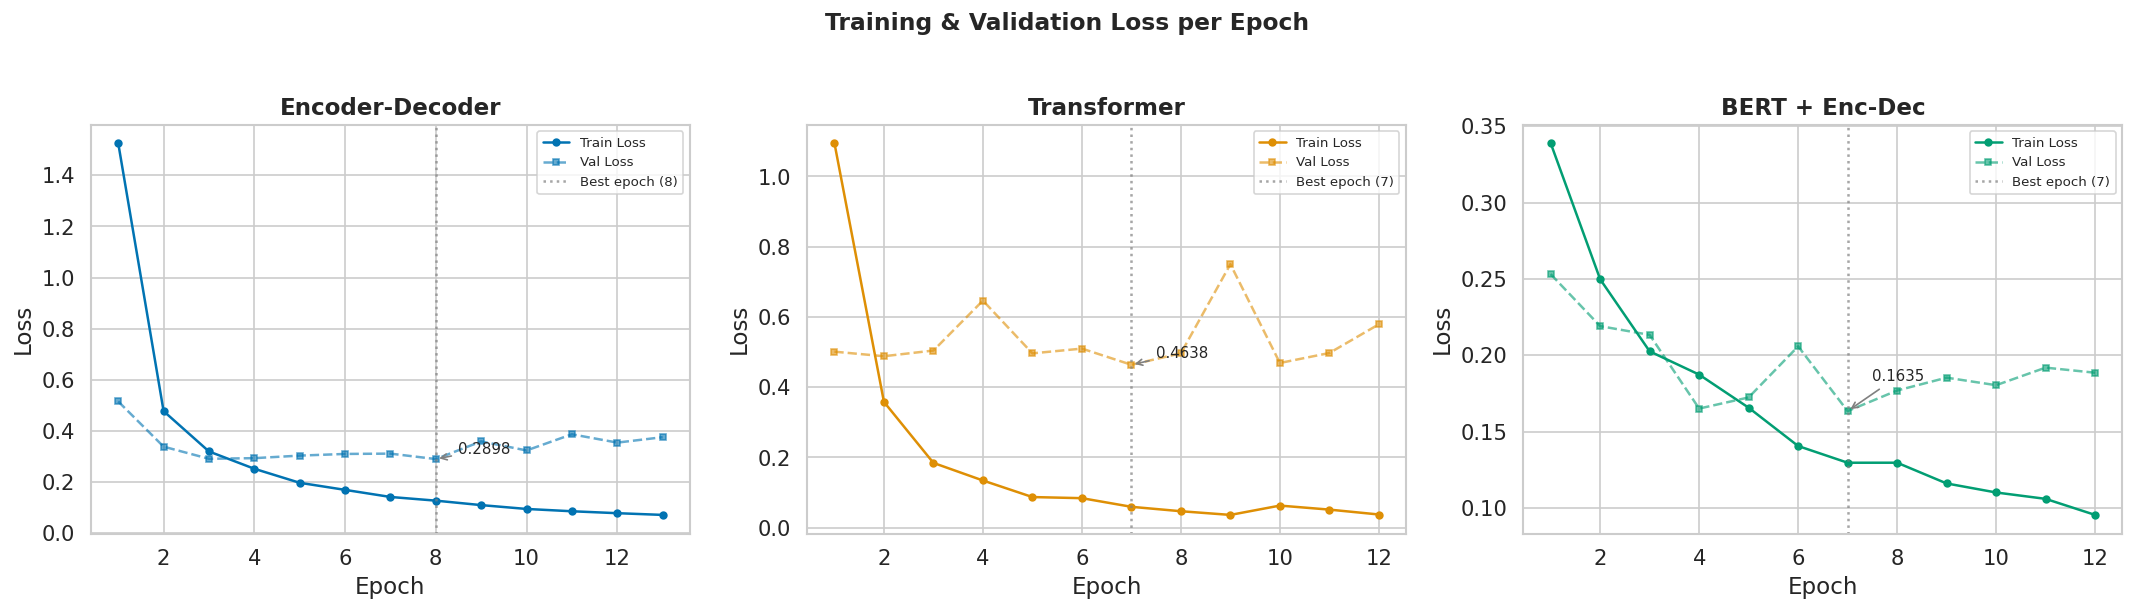

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

histories = [h1, h2, h3]

for idx, (h, name, color) in enumerate(zip(histories, MODEL_NAMES, COLORS)):
    ax = axes[idx]
    epochs = range(1, len(h['train_loss']) + 1)
    ax.plot(epochs, h['train_loss'], '-o', color=color, label='Train Loss', markersize=4)
    ax.plot(epochs, h['val_loss'], '-s', color=color, alpha=0.6, label='Val Loss', markersize=4, linestyle='--')
    
    # Mark best val loss epoch
    best_epoch = np.argmin(h['val_loss']) + 1
    best_val = min(h['val_loss'])
    ax.axvline(x=best_epoch, color='gray', linestyle=':', alpha=0.7, label=f'Best epoch ({best_epoch})')
    ax.annotate(f'{best_val:.4f}', xy=(best_epoch, best_val), fontsize=9,
                xytext=(best_epoch + 0.5, best_val + 0.02), arrowprops=dict(arrowstyle='->', color='gray'))
    
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend(fontsize=8)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

fig.suptitle('Training & Validation Loss per Epoch', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('report_loss_curves.png', bbox_inches='tight')
plt.show()

---
## 4. Training Dynamics — All Models on One Plot

Overlaying the validation loss curves makes it easy to compare convergence speed and final performance.

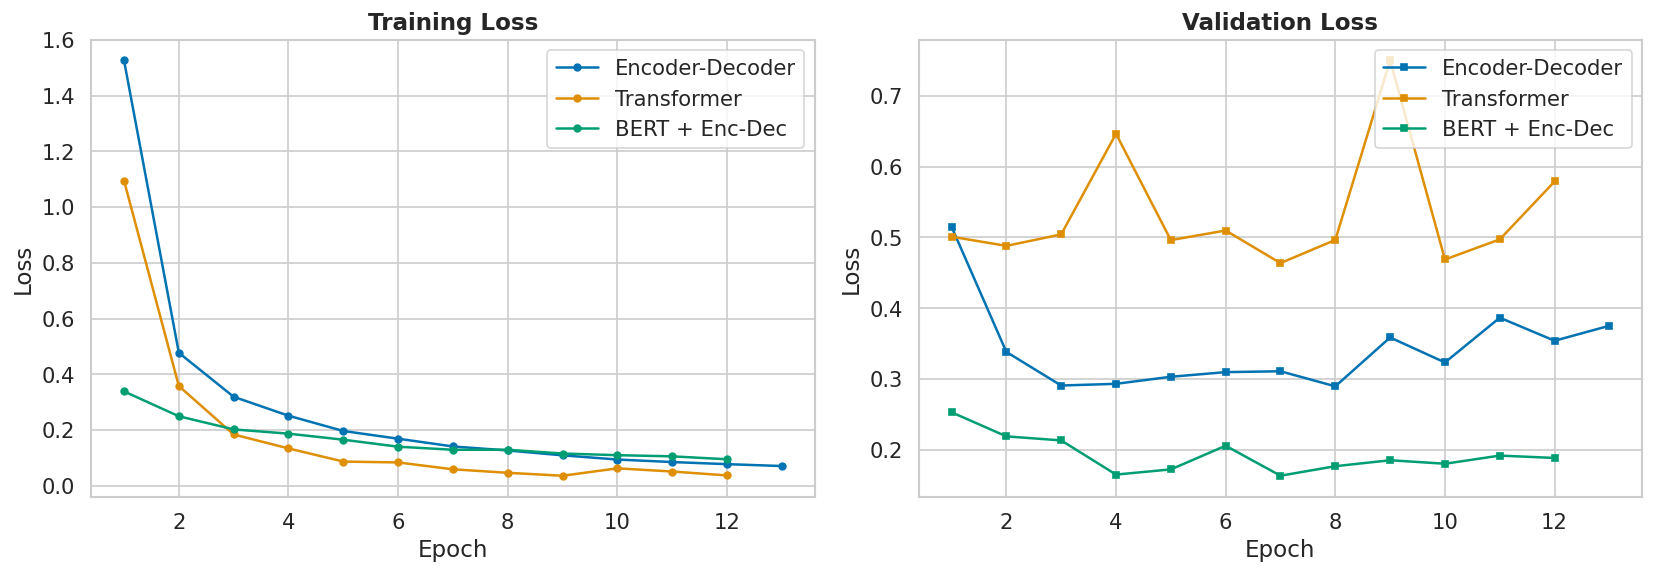

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Train loss overlay
for h, name, color in zip(histories, MODEL_NAMES, COLORS):
    epochs = range(1, len(h['train_loss']) + 1)
    axes[0].plot(epochs, h['train_loss'], '-o', color=color, label=name, markersize=4)
axes[0].set_title('Training Loss', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# Val loss overlay
for h, name, color in zip(histories, MODEL_NAMES, COLORS):
    epochs = range(1, len(h['val_loss']) + 1)
    axes[1].plot(epochs, h['val_loss'], '-s', color=color, label=name, markersize=4)
axes[1].set_title('Validation Loss', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.savefig('report_loss_overlay.png', bbox_inches='tight')
plt.show()

---
## 7. Test Set Performance — Final Comparison

The table and bar charts below summarize the final test-set performance of each model.


=== Test Set Performance ===
          Model  Intent Accuracy  Slot F1  Joint Accuracy
Encoder-Decoder           0.9757   0.8791          0.6200
    Transformer           0.9857   0.8457          0.5500
 BERT + Enc-Dec           0.9843   0.9467          0.8357


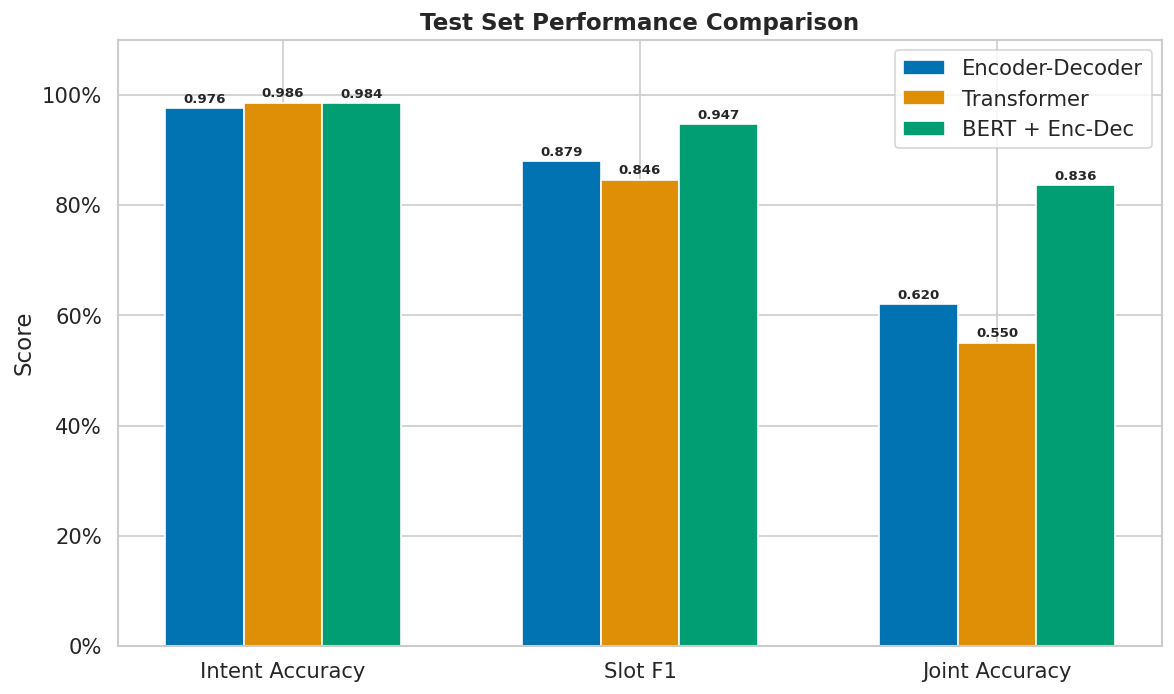

In [8]:
test_df = pd.DataFrame({
    'Model': MODEL_NAMES,
    'Intent Accuracy': [tm1['intent_accuracy'], tm2['intent_accuracy'], tm3['intent_accuracy']],
    'Slot F1': [tm1['slot_f1'], tm2['slot_f1'], tm3['slot_f1']],
    'Joint Accuracy': [tm1['joint_accuracy'], tm2['joint_accuracy'], tm3['joint_accuracy']],
})

print('\n=== Test Set Performance ===')
print(test_df.to_string(index=False, float_format='%.4f'))

# Grouped bar chart
metrics = ['Intent Accuracy', 'Slot F1', 'Joint Accuracy']
x = np.arange(len(metrics))
width = 0.22

fig, ax = plt.subplots(figsize=(10, 6))

for i, (name, color) in enumerate(zip(MODEL_NAMES, COLORS)):
    vals = [test_df.loc[i, m] for m in metrics]
    bars = ax.bar(x + i * width, vals, width, label=name, color=color)
    # Add value labels on bars
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_ylabel('Score')
ax.set_title('Test Set Performance Comparison', fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.10)
ax.legend()
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0, decimals=0))

plt.tight_layout()
plt.savefig('report_test_comparison.png', bbox_inches='tight')
plt.show()

---
## 12. Best Validation Metrics Summary

In [13]:
best_df = pd.DataFrame({
    'Model': MODEL_NAMES,
    'Best Val Loss': [min(h['val_loss']) for h in histories],
    'Best Val Loss Epoch': [np.argmin(h['val_loss']) + 1 for h in histories],
    'Best Intent Acc': [max(h['intent_acc']) for h in histories],
    'Best Intent Acc Epoch': [np.argmax(h['intent_acc']) + 1 for h in histories],
    'Best Slot F1': [max(h['slot_f1']) for h in histories],
    'Best Slot F1 Epoch': [np.argmax(h['slot_f1']) + 1 for h in histories],
})

print('Best Validation Metrics Across Training:')
print(best_df.to_string(index=False, float_format='%.4f'))

Best Validation Metrics Across Training:
          Model  Best Val Loss  Best Val Loss Epoch  Best Intent Acc  Best Intent Acc Epoch  Best Slot F1  Best Slot F1 Epoch
Encoder-Decoder         0.2898                    8           0.9871                     13        0.9065                  10
    Transformer         0.4638                    7           0.9871                      1        0.8696                   7
 BERT + Enc-Dec         0.1635                    7           0.9871                      4        0.9497                   7


---
## 13. Detailed Findings & Analysis

### Intent Classification
All three models achieve **high intent accuracy (97–99%)** on the test set, with the Transformer model slightly leading. This suggests that intent classification on SNIPS is relatively easy for all architectures — the utterance-level semantics are well captured regardless of the encoder type.

### Slot Filling
Slot filling is the more challenging task and is where the models diverge significantly:

- **BERT + Encoder-Decoder** achieves the highest slot F1, thanks to BERT's pre-trained contextualized embeddings which encode rich subword and syntactic information.
- **Encoder-Decoder** with learned embeddings performs second-best, showing that the GRU encoder-decoder framework is effective for sequence labeling.
- **Transformer** struggles more with slot F1. Without pre-trained weights, the self-attention layers require more data to learn positional slot patterns.

### Joint Accuracy
Joint accuracy (both intent and all slots correct simultaneously) is the most stringent metric:

- **BERT + Encoder-Decoder** dominates with the highest joint accuracy, confirming that pre-trained representations provide a substantial advantage.
- The Encoder-Decoder with learned embeddings comes second.
- The Transformer model lags behind on joint accuracy, largely due to its lower slot F1.

### Convergence & Early Stopping
All models triggered early stopping before reaching the maximum 20 epochs, indicating that:
1. Early stopping effectively prevents overfitting.
2. The models converge relatively quickly on this dataset (~7–13 epochs).

### Parameter Efficiency
- **BERT + Encoder-Decoder** has only ~1.1M trainable parameters (the rest are frozen BERT weights), yet achieves the best results. This demonstrates the power of transfer learning.
- **Encoder-Decoder** has ~4.6M trainable parameters and achieves solid results.
- **Transformer** has ~6.7M trainable parameters but underperforms, suggesting it needs either more data, pre-training, or hyperparameter tuning.

### Overfitting Behavior
- The **Transformer** shows the largest overfitting gap (val loss >> train loss), which is expected for a model with many parameters and no pre-training.
- **BERT + Encoder-Decoder** generalizes best, with the smallest gap, benefiting from BERT's learned representations.
- **Encoder-Decoder** falls in between.

---
## 14. Final Summary Table

In [14]:
summary_df = pd.DataFrame({
    'Model': MODEL_NAMES,
    'Trainable Params': [f"{mp['model1_trainable']:,}", f"{mp['model2_trainable']:,}", f"{mp['model3_trainable']:,}"],
    'Epochs': [len(h1['train_loss']), len(h2['train_loss']), len(h3['train_loss'])],
    'Test Intent Acc': [f"{tm1['intent_accuracy']:.2%}", f"{tm2['intent_accuracy']:.2%}", f"{tm3['intent_accuracy']:.2%}"],
    'Test Slot F1': [f"{tm1['slot_f1']:.2%}", f"{tm2['slot_f1']:.2%}", f"{tm3['slot_f1']:.2%}"],
    'Test Joint Acc': [f"{tm1['joint_accuracy']:.2%}", f"{tm2['joint_accuracy']:.2%}", f"{tm3['joint_accuracy']:.2%}"],
    'Best Val Loss': [f"{min(h1['val_loss']):.4f}", f"{min(h2['val_loss']):.4f}", f"{min(h3['val_loss']):.4f}"],
})

print('=' * 100)
print('FINAL COMPARISON SUMMARY')
print('=' * 100)
print(summary_df.to_string(index=False))
print('\n🏆  Best overall model: BERT + Encoder-Decoder')
print('    Highest Slot F1, highest Joint Accuracy, fewest trainable parameters.')

FINAL COMPARISON SUMMARY
          Model Trainable Params  Epochs Test Intent Acc Test Slot F1 Test Joint Acc Best Val Loss
Encoder-Decoder        4,608,272      13          97.57%       87.91%         62.00%        0.2898
    Transformer        6,656,336      12          98.57%       84.57%         55.00%        0.4638
 BERT + Enc-Dec        1,110,608      12          98.43%       94.67%         83.57%        0.1635

🏆  Best overall model: BERT + Encoder-Decoder
    Highest Slot F1, highest Joint Accuracy, fewest trainable parameters.


---
## 15. Conclusions & Recommendations

1. **BERT + Encoder-Decoder is the clear winner** across all key metrics (slot F1, joint accuracy), while being the most parameter-efficient in terms of trainable weights.

2. **Encoder-Decoder with learned embeddings** is a strong baseline that trains fast and achieves competitive results without external pre-training.

3. **The Transformer model** — while powerful in theory — underperforms without pre-training on this relatively small dataset (~13K training samples). It would likely benefit from:
   - Pre-training on a larger corpus
   - Using a pre-trained transformer (like using BERT as the transformer encoder directly)
   - More aggressive regularization or data augmentation

4. **Early stopping** proved essential: all models started overfitting after epoch 7–8, and training beyond that point only degraded validation performance.

5. **Transfer learning** (Model 3) provides the biggest boost for slot filling, suggesting that word-level contextual representations from large language models substantially improve sequence labeling tasks.